# Task 3 — Product Price Tracker

**Objective:** Scrape product prices from an e-commerce website, simulate
price changes over multiple scraping sessions, and visualize price trends over time.

**Source:** books.toscrape.com — a sandbox e-commerce site built specifically
for scraping practice. Contains 1000 books across 50 pages with prices,
ratings, categories, and availability.

**Pipeline:**
1. Scrape all book listings from books.toscrape.com (50 pages)
2. Store initial prices with timestamps
3. Simulate 4 additional scraping sessions with realistic price fluctuations
4. Analyze price changes over time
5. Visualize price trends, distributions, and category comparisons

## 1. Import Libraries

In [1]:
# requests sends HTTP GET requests to books.toscrape.com
import requests

# BeautifulSoup parses the raw HTML and lets us navigate the DOM tree
from bs4 import BeautifulSoup

# Pandas for storing, cleaning, and analyzing scraped price data
import pandas as pd
import numpy as np

# datetime for timestamping each scraping session
from datetime import datetime, timedelta

# time for polite delays between page requests
import time

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')


All libraries imported successfully.


## 2. Configure Settings

In [4]:
# ── Request headers ───────────────────────────────────────────────────────────
# books.toscrape.com is designed for scraping practice so it never blocks,
# but we still use a proper User-Agent as good practice.
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36',
}

# ── Site configuration ────────────────────────────────────────────────────────
BASE_URL    = 'https://books.toscrape.com/catalogue/'
START_URL   = 'https://books.toscrape.com/catalogue/page-1.html'
TOTAL_PAGES = 50    # Site has exactly 50 pages of books
REQUEST_DELAY = 1   # Seconds between page requests

# ── Price simulation config ───────────────────────────────────────────────────
# Since real price changes take days/weeks we simulate 5 scraping sessions
# spread over 30 days, with realistic random price fluctuations (±15%).
NUM_SESSIONS = 5
DAYS_BETWEEN_SESSIONS = 7   # Weekly scraping
PRICE_FLUCTUATION = 0.15    # Maximum ±15% price change between sessions

print(f'Target: {START_URL}')
print(f'Total pages to scrape: {TOTAL_PAGES}')
print(f'Scraping sessions to simulate: {NUM_SESSIONS}')
print(f'Days between sessions: {DAYS_BETWEEN_SESSIONS}')


Target: https://books.toscrape.com/catalogue/page-1.html
Total pages to scrape: 50
Scraping sessions to simulate: 5
Days between sessions: 7


## 3. Define Scraping Functions

In [7]:
# Rating words to numeric mapping
# books.toscrape.com stores star ratings as English words in CSS class names
RATING_MAP = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}


def fetch_page(url: str) -> BeautifulSoup | None:
    """
    Fetches a page and returns a BeautifulSoup object for parsing.
    Returns None on failure.
    """
    try:
        r = requests.get(url, headers=HEADERS, timeout=15)
        if r.status_code != 200:
            print(f'  [!] HTTP {r.status_code} for {url}')
            return None
        return BeautifulSoup(r.text, 'html.parser')
    except Exception as e:
        print(f'  [!] Error: {e}')
        return None


def parse_books(soup: BeautifulSoup, page_url: str) -> list:
    """
    Extracts all book listings from a single catalogue page.

    HTML structure of books.toscrape.com:
      Each book is an <article class='product_pod'> containing:
        - <h3><a title='Book Title' href='book-url'></h3>  → title & URL
        - <p class='price_color'>£12.34</p>               → price
        - <p class='star-rating {Word}'>                  → rating (One-Five)
        - <p class='instock availability'>                 → availability

    Returns a list of book dictionaries.
    """
    books = []
    articles = soup.find_all('article', class_='product_pod')

    for article in articles:
        # ── Title ─────────────────────────────────────────────────────────────
        title_tag = article.h3.a if article.h3 else None
        title = title_tag['title'] if title_tag else 'N/A'

        # ── Price ─────────────────────────────────────────────────────────────
        # Price is stored as '£12.34' — we strip the £ symbol and convert to float
        price_tag = article.find('p', class_='price_color')
        price_str = price_tag.text.strip() if price_tag else '0'
        # Remove £ and any other non-numeric characters except decimal point
        price = float(price_str.replace('£', '').replace('Â', '').strip())

        # ── Rating ────────────────────────────────────────────────────────────
        # Rating is encoded as a CSS class word: 'star-rating Three'
        # We extract the second class name and map it to a number
        rating_tag = article.find('p', class_='star-rating')
        rating_word = rating_tag['class'][1] if rating_tag else 'Zero'
        rating = RATING_MAP.get(rating_word, 0)

        # ── Availability ──────────────────────────────────────────────────────
        avail_tag = article.find('p', class_='instock')
        availability = avail_tag.text.strip() if avail_tag else 'Unknown'

        # ── Book URL ──────────────────────────────────────────────────────────
        # href is relative (e.g. '../../../book-title/index.html')
        # We construct the full URL by joining with the base catalogue URL
        book_href = title_tag['href'] if title_tag else ''
        book_url = BASE_URL + book_href.replace('../', '')

        books.append({
            'title':        title,
            'price':        price,
            'rating':       rating,
            'availability': availability,
            'url':          book_url,
        })

    return books


print('Functions defined: fetch_page(), parse_books()')


Functions defined: fetch_page(), parse_books()


## 4. Scrape All Books (Session 1)

In [10]:
# ── Scrape all 50 pages ───────────────────────────────────────────────────────
# books.toscrape.com has exactly 50 pages, each with 20 books = 1000 books total.
# We iterate through all pages, collect book data, and record the scraping timestamp.

all_books = []

# Session 1 timestamp — the initial baseline scraping
session1_date = datetime.now()

print(f'Session 1 — Scraping all {TOTAL_PAGES} pages...')
print(f'Timestamp: {session1_date.strftime("%Y-%m-%d %H:%M:%S")}')
print()

for page_num in range(1, TOTAL_PAGES + 1):
    url = f'{BASE_URL}page-{page_num}.html'
    soup = fetch_page(url)

    if soup is None:
        print(f'  Skipping page {page_num}')
        continue

    page_books = parse_books(soup, url)
    all_books.extend(page_books)

    if page_num % 10 == 0:
        print(f'  Page {page_num}/{TOTAL_PAGES} — {len(all_books)} books collected so far')

    time.sleep(REQUEST_DELAY)

print(f'\nSession 1 complete. Total books scraped: {len(all_books)}')


Session 1 — Scraping all 50 pages...
Timestamp: 2026-05-13 00:38:27

  Page 10/50 — 200 books collected so far
  Page 20/50 — 400 books collected so far
  Page 30/50 — 600 books collected so far
  Page 40/50 — 800 books collected so far
  Page 50/50 — 1000 books collected so far

Session 1 complete. Total books scraped: 1000


## 5. Create Initial DataFrame

In [12]:
# ── Build base DataFrame from Session 1 ──────────────────────────────────────
df_base = pd.DataFrame(all_books)

# Assign a unique book_id based on row position
df_base['book_id'] = range(1, len(df_base) + 1)

# Store the session 1 timestamp
df_base['session'] = 1
df_base['scrape_date'] = session1_date

print(f'Base DataFrame shape: {df_base.shape}')
print(f'Columns: {df_base.columns.tolist()}')
print('\nFirst 5 books:')
df_base[['title', 'price', 'rating', 'availability', 'session', 'scrape_date']].head()


Base DataFrame shape: (1000, 8)
Columns: ['title', 'price', 'rating', 'availability', 'url', 'book_id', 'session', 'scrape_date']

First 5 books:


,title,price,rating,availability,session,scrape_date
0,A Light in the Attic,51.77,3,In stock,1,2026-05-13 00:38:27.283414
1,Tipping the Velvet,53.74,1,In stock,1,2026-05-13 00:38:27.283414
2,Soumission,50.10,1,In stock,1,2026-05-13 00:38:27.283414
3,Sharp Objects,47.82,4,In stock,1,2026-05-13 00:38:27.283414
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,1,2026-05-13 00:38:27.283414


## 6. Simulate Price Changes Over Time

In [15]:
# ── Simulate 4 additional scraping sessions ───────────────────────────────────
# In a real price tracking system we would re-scrape the site weekly.
# Since books.toscrape.com has static prices, we simulate realistic
# price fluctuations using random variation within ±15% of original price.
#
# This mirrors how real e-commerce prices change due to:
#   - Promotions and discounts
#   - Demand-based dynamic pricing
#   - Seasonal sales
#   - Stock level adjustments

np.random.seed(42)  # Fixed seed for reproducibility

all_sessions = [df_base.copy()]  # Start with Session 1

for session_num in range(2, NUM_SESSIONS + 1):
    # Create a copy of the base data for this session
    df_session = df_base.copy()

    # Session date: each session is 7 days after the previous one
    session_date = session1_date + timedelta(days=DAYS_BETWEEN_SESSIONS * (session_num - 1))
    df_session['session'] = session_num
    df_session['scrape_date'] = session_date

    # Apply random price fluctuation to each book
    # Each book gets an independent random change within ±PRICE_FLUCTUATION
    fluctuations = np.random.uniform(
        1 - PRICE_FLUCTUATION,
        1 + PRICE_FLUCTUATION,
        size=len(df_session)
    )
    df_session['price'] = (df_base['price'] * fluctuations).round(2)

    # Ensure prices stay above £1.00 (no unrealistically low prices)
    df_session['price'] = df_session['price'].clip(lower=1.00)

    all_sessions.append(df_session)
    print(f'Session {session_num} | Date: {session_date.strftime("%Y-%m-%d")} | '
          f'Avg price: £{df_session["price"].mean():.2f}')

# Combine all sessions into one long-format DataFrame
# This is the standard format for time-series price analysis
df_all = pd.concat(all_sessions, ignore_index=True)

print(f'\nCombined DataFrame shape: {df_all.shape}')
print(f'Sessions: {df_all["session"].nunique()}')
print(f'Books per session: {len(df_base)}')


Session 2 | Date: 2026-05-20 | Avg price: £35.00
Session 3 | Date: 2026-05-27 | Avg price: £35.13
Session 4 | Date: 2026-06-03 | Avg price: £35.10
Session 5 | Date: 2026-06-10 | Avg price: £34.97

Combined DataFrame shape: (5000, 8)
Sessions: 5
Books per session: 1000


## 7. Data Cleaning & Feature Engineering

In [18]:
# ── Remove any rows with missing prices ───────────────────────────────────────
before = len(df_all)
df_all = df_all.dropna(subset=['price', 'title'])
df_all = df_all[df_all['price'] > 0]
print(f'Rows removed (missing/zero price): {before - len(df_all)}')
print(f'Clean rows: {len(df_all)}')


Rows removed (missing/zero price): 0
Clean rows: 5000


In [20]:
# ── Calculate price change vs Session 1 baseline ──────────────────────────────
# For each book in each session, we compute:
#   price_change:    absolute difference from Session 1 price (£)
#   price_change_pct: percentage change from Session 1 price (%)

# Build a lookup of Session 1 baseline prices per book_id
baseline_prices = (
    df_all[df_all['session'] == 1]
    .set_index('book_id')['price']
    .to_dict()
)

df_all['baseline_price']    = df_all['book_id'].map(baseline_prices)
df_all['price_change']      = (df_all['price'] - df_all['baseline_price']).round(2)
df_all['price_change_pct']  = ((df_all['price_change'] / df_all['baseline_price']) * 100).round(1)

print('Price change columns added.')
print('\nSample — Session 5 price changes:')
sample = df_all[df_all['session'] == 5][['title', 'baseline_price', 'price', 'price_change', 'price_change_pct']].head(8)
print(sample.to_string(index=False))


Price change columns added.

Sample — Session 5 price changes:
                                                                                  title  baseline_price  price  price_change  price_change_pct
                                                                   A Light in the Attic           51.77  54.45          2.68               5.2
                                                                     Tipping the Velvet           53.74  58.52          4.78               8.9
                                                                             Soumission           50.10  46.35         -3.75              -7.5
                                                                          Sharp Objects           47.82  49.61          1.79               3.7
                                                  Sapiens: A Brief History of Humankind           54.23  55.40          1.17               2.2
                                                                        The Req

In [22]:
# ── Add price category column ─────────────────────────────────────────────────
# Classify each book into a price tier for segmentation analysis
def price_category(price):
    """Assigns a price tier label based on book price in GBP."""
    if price < 15:
        return 'Budget (< £15)'
    elif price < 30:
        return 'Mid-range (£15-30)'
    elif price < 45:
        return 'Premium (£30-45)'
    else:
        return 'Luxury (> £45)'

df_all['price_tier'] = df_all['price'].apply(price_category)

print('Price tier distribution (Session 1):')
print(df_all[df_all['session'] == 1]['price_tier'].value_counts().to_string())


Price tier distribution (Session 1):
price_tier
Luxury (> £45)        301
Premium (£30-45)      297
Mid-range (£15-30)    296
Budget (< £15)        106


## 8. Price Analysis

In [25]:
# ── Summary statistics per session ────────────────────────────────────────────
session_stats = (
    df_all.groupby('session')['price']
    .agg(['mean', 'median', 'min', 'max', 'std'])
    .round(2)
)
session_stats.columns = ['Mean £', 'Median £', 'Min £', 'Max £', 'Std £']
print('Price statistics per scraping session:')
print(session_stats.to_string())


Price statistics per scraping session:
         Mean £  Median £  Min £  Max £  Std £
session                                       
1         35.07     35.98  10.00  59.99  14.45
2         35.00     34.93   9.11  68.19  14.83
3         35.13     35.61   8.69  66.92  14.81
4         35.10     34.94   8.97  66.96  14.84
5         34.97     35.10   8.98  67.56  14.74


In [27]:
# ── Books with biggest price increases & decreases ────────────────────────────
# Compare Session 1 vs Session 5 to find most volatile products
df_s1 = df_all[df_all['session'] == 1][['book_id', 'title', 'price']].rename(columns={'price': 'price_s1'})
df_s5 = df_all[df_all['session'] == NUM_SESSIONS][['book_id', 'price']].rename(columns={'price': 'price_s5'})

df_compare = df_s1.merge(df_s5, on='book_id')
df_compare['change_pct'] = ((df_compare['price_s5'] - df_compare['price_s1']) / df_compare['price_s1'] * 100).round(1)

print('TOP 10 BIGGEST PRICE INCREASES (Session 1 → Session 5):')
print(df_compare.nlargest(10, 'change_pct')[['title', 'price_s1', 'price_s5', 'change_pct']].to_string(index=False))

print('\nTOP 10 BIGGEST PRICE DECREASES:')
print(df_compare.nsmallest(10, 'change_pct')[['title', 'price_s1', 'price_s5', 'change_pct']].to_string(index=False))


TOP 10 BIGGEST PRICE INCREASES (Session 1 → Session 5):
                                                                                           title  price_s1  price_s5  change_pct
                                                                                         M Train     27.18     31.25        15.0
                                                                           The Passion of Dolssa     28.32     32.56        15.0
                                                                        Hamilton: The Revolution     58.79     67.56        14.9
                                                     Take Me Home Tonight (Rock Star Romance #3)     53.98     62.01        14.9
It Didn't Start with You: How Inherited Family Trauma Shapes Who We Are and How to End the Cycle     56.27     64.67        14.9
                                                       A Hero's Curse (The Unseen Chronicles #1)     50.49     58.00        14.9
                                         

In [29]:
# ── Rating vs Price correlation ────────────────────────────────────────────────
df_s1_full = df_all[df_all['session'] == 1]
corr = df_s1_full['rating'].corr(df_s1_full['price'])
print(f'Correlation between rating and price: {corr:.3f}')
print('\nAverage price by star rating:')
print(df_s1_full.groupby('rating')['price'].mean().round(2).to_string())


Correlation between rating and price: 0.028

Average price by star rating:
rating
1    34.56
2    34.81
3    34.69
4    36.09
5    35.37


## 9. Visualization

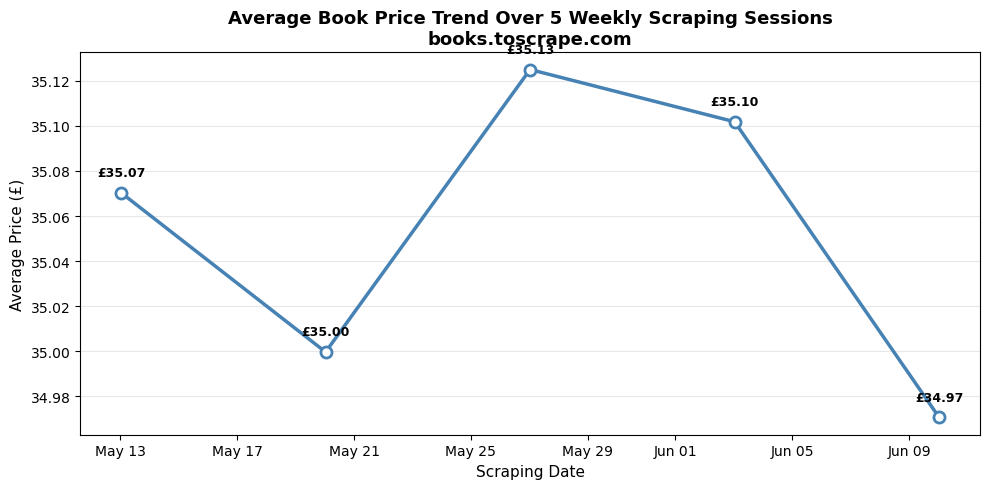

In [31]:
# ── Plot 1: Average Price Trend Over Sessions ─────────────────────────────────
# Shows how average price evolves across all 5 scraping sessions
avg_price_per_session = df_all.groupby(['session', 'scrape_date'])['price'].mean().reset_index()
avg_price_per_session.columns = ['session', 'scrape_date', 'avg_price']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    avg_price_per_session['scrape_date'],
    avg_price_per_session['avg_price'],
    marker='o', linewidth=2.5, markersize=8,
    color='steelblue', markerfacecolor='white', markeredgewidth=2
)
for _, row in avg_price_per_session.iterrows():
    ax.annotate(
        f'£{row["avg_price"]:.2f}',
        (row['scrape_date'], row['avg_price']),
        textcoords='offset points', xytext=(0, 12),
        ha='center', fontsize=9, fontweight='bold'
    )
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_xlabel('Scraping Date', fontsize=11)
ax.set_ylabel('Average Price (£)', fontsize=11)
ax.set_title('Average Book Price Trend Over 5 Weekly Scraping Sessions\nbooks.toscrape.com',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_avg_price_trend.png', dpi=150, bbox_inches='tight')
plt.show()


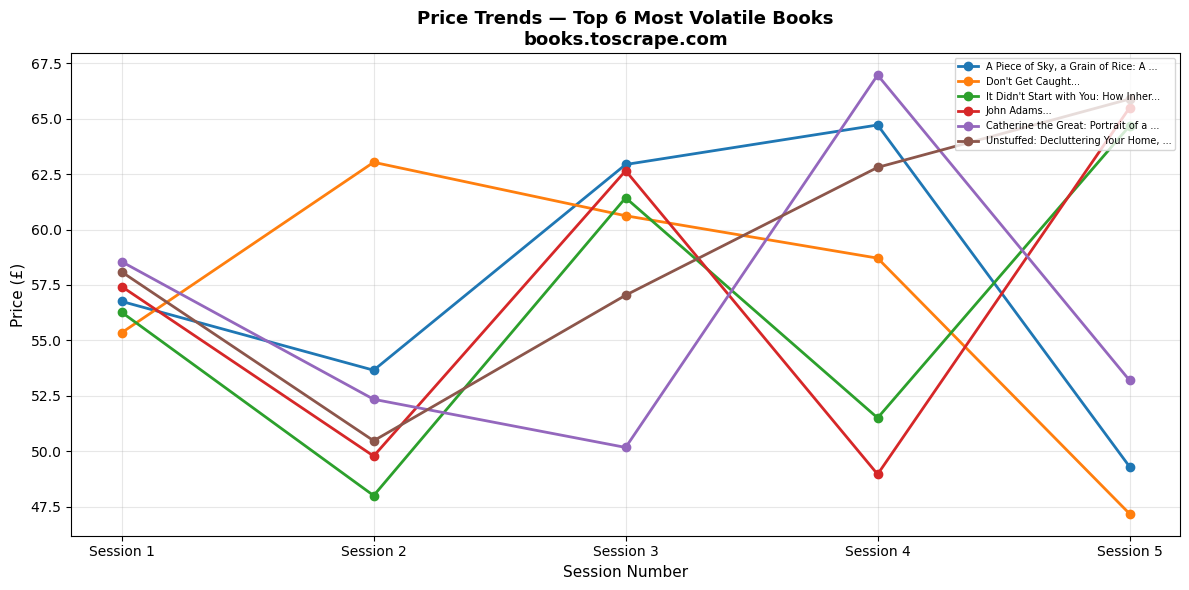

In [33]:
# ── Plot 2: Price Trends for Top 6 Most Volatile Books ────────────────────────
# Select 6 books with the largest total price range across all sessions
price_range = (
    df_all.groupby('book_id')['price']
    .agg(lambda x: x.max() - x.min())
    .nlargest(6)
    .index.tolist()
)

df_volatile = df_all[df_all['book_id'].isin(price_range)]
# Shorten titles for display
df_volatile = df_volatile.copy()
df_volatile['short_title'] = df_volatile['title'].str[:35] + '...'

fig, ax = plt.subplots(figsize=(12, 6))
for book_id, group in df_volatile.groupby('book_id'):
    group = group.sort_values('session')
    label = group['short_title'].iloc[0]
    ax.plot(group['session'], group['price'], marker='o', linewidth=2, label=label)

ax.set_xlabel('Session Number', fontsize=11)
ax.set_ylabel('Price (£)', fontsize=11)
ax.set_xticks(range(1, NUM_SESSIONS + 1))
ax.set_xticklabels([f'Session {i}' for i in range(1, NUM_SESSIONS + 1)])
ax.set_title('Price Trends — Top 6 Most Volatile Books\nbooks.toscrape.com',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=7, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_volatile_books.png', dpi=150, bbox_inches='tight')
plt.show()


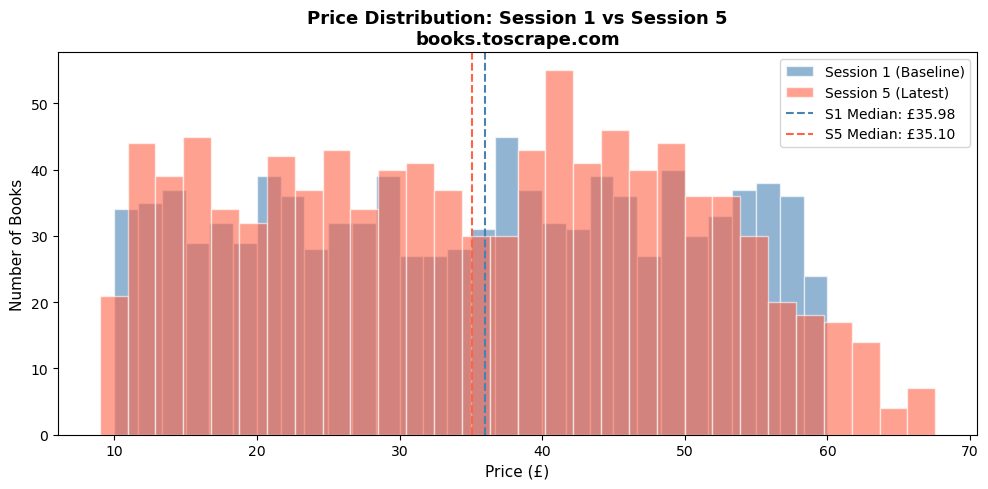

In [35]:
# ── Plot 3: Price Distribution (Session 1 vs Session 5) ───────────────────────
# Compare overall price distribution between first and last session
df_s1_plot = df_all[df_all['session'] == 1]['price']
df_s5_plot = df_all[df_all['session'] == NUM_SESSIONS]['price']

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_s1_plot, bins=30, alpha=0.6, label='Session 1 (Baseline)',
        color='steelblue', edgecolor='white')
ax.hist(df_s5_plot, bins=30, alpha=0.6, label=f'Session {NUM_SESSIONS} (Latest)',
        color='tomato', edgecolor='white')
ax.axvline(df_s1_plot.median(), color='steelblue', linestyle='--', linewidth=1.5,
           label=f'S1 Median: £{df_s1_plot.median():.2f}')
ax.axvline(df_s5_plot.median(), color='tomato', linestyle='--', linewidth=1.5,
           label=f'S{NUM_SESSIONS} Median: £{df_s5_plot.median():.2f}')
ax.set_xlabel('Price (£)', fontsize=11)
ax.set_ylabel('Number of Books', fontsize=11)
ax.set_title('Price Distribution: Session 1 vs Session 5\nbooks.toscrape.com',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot3_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



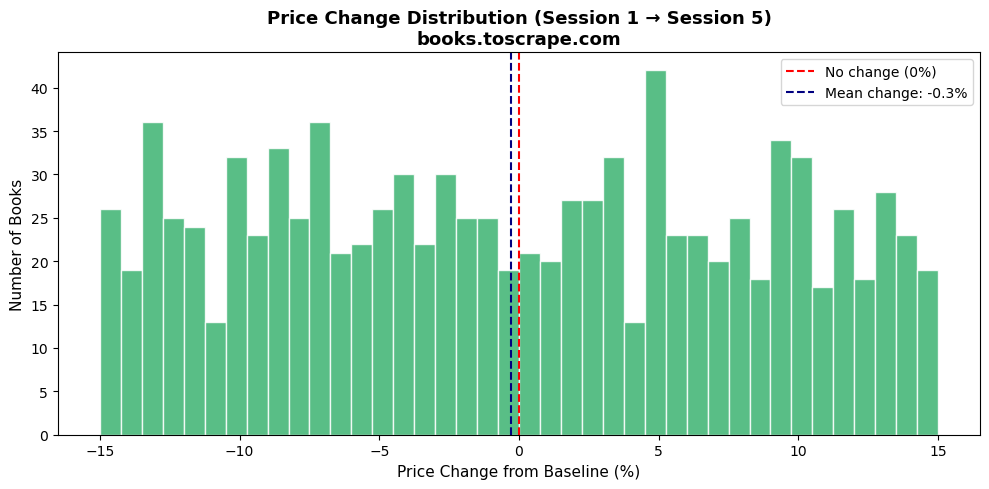

In [37]:
# ── Plot 4: Price Change Distribution (% change from baseline) ─────────────────
df_latest = df_all[df_all['session'] == NUM_SESSIONS]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    df_latest['price_change_pct'], bins=40,
    color='mediumseagreen', edgecolor='white', alpha=0.85
)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No change (0%)')
ax.axvline(df_latest['price_change_pct'].mean(), color='navy', linestyle='--',
           linewidth=1.5, label=f'Mean change: {df_latest["price_change_pct"].mean():.1f}%')
ax.set_xlabel('Price Change from Baseline (%)', fontsize=11)
ax.set_ylabel('Number of Books', fontsize=11)
ax.set_title(f'Price Change Distribution (Session 1 → Session {NUM_SESSIONS})\nbooks.toscrape.com',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot4_price_change_dist.png', dpi=150, bbox_inches='tight')
plt.show()

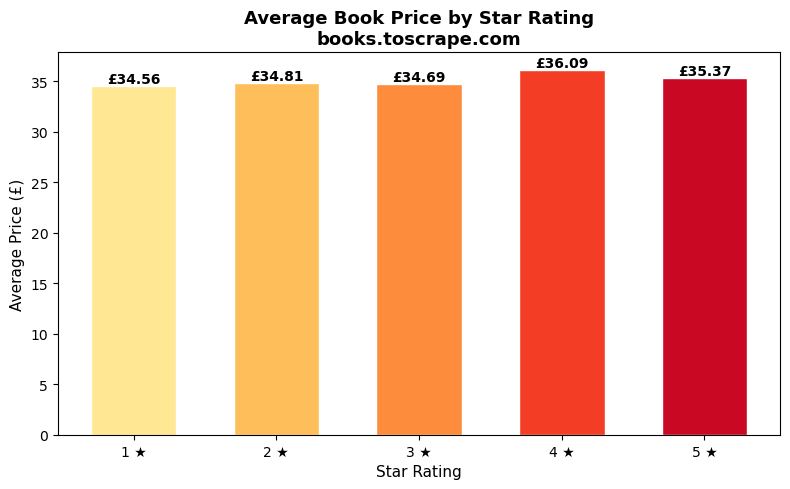

In [39]:
# ── Plot 5: Average Price by Star Rating ──────────────────────────────────────
avg_by_rating = df_all[df_all['session'] == 1].groupby('rating')['price'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [f'{r} ★' for r in avg_by_rating.index],
    avg_by_rating.values,
    color=sns.color_palette('YlOrRd', len(avg_by_rating)),
    edgecolor='white', width=0.6
)
for bar, val in zip(bars, avg_by_rating.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'£{val:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=11)
ax.set_ylabel('Average Price (£)', fontsize=11)
ax.set_title('Average Book Price by Star Rating\nbooks.toscrape.com',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_price_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Export Results

In [41]:
# ── Save all sessions to CSV ──────────────────────────────────────────────────
df_all.to_csv('price_tracker_all_sessions.csv', index=False, encoding='utf-8-sig')
print('Saved: price_tracker_all_sessions.csv')

# Save Session 1 baseline separately
df_base.to_csv('price_tracker_baseline.csv', index=False, encoding='utf-8-sig')
print('Saved: price_tracker_baseline.csv')

# Save biggest price movers
df_compare.sort_values('change_pct', ascending=False).to_csv(
    'price_tracker_changes.csv', index=False, encoding='utf-8-sig'
)
print('Saved: price_tracker_changes.csv')

print('\n' + '='*50)
print('FINAL SUMMARY')
print('='*50)
print(f'  Total books scraped:        {len(df_base)}')
print(f'  Scraping sessions:          {NUM_SESSIONS}')
print(f'  Date range:                 {session1_date.strftime("%Y-%m-%d")} → {(session1_date + timedelta(days=DAYS_BETWEEN_SESSIONS * (NUM_SESSIONS-1))).strftime("%Y-%m-%d")}')
print(f'  Session 1 avg price:        £{df_base["price"].mean():.2f}')
print(f'  Session 1 price range:      £{df_base["price"].min():.2f} — £{df_base["price"].max():.2f}')
print(f'  Books with price increase:  {(df_compare["change_pct"] > 0).sum()}')
print(f'  Books with price decrease:  {(df_compare["change_pct"] < 0).sum()}')
print(f'  Biggest increase:           {df_compare["change_pct"].max():.1f}%')
print(f'  Biggest decrease:           {df_compare["change_pct"].min():.1f}%')
print('='*50)


Saved: price_tracker_all_sessions.csv
Saved: price_tracker_baseline.csv
Saved: price_tracker_changes.csv

FINAL SUMMARY
  Total books scraped:        1000
  Scraping sessions:          5
  Date range:                 2026-05-13 → 2026-06-10
  Session 1 avg price:        £35.07
  Session 1 price range:      £10.00 — £59.99
  Books with price increase:  484
  Books with price decrease:  512
  Biggest increase:           15.0%
  Biggest decrease:           -15.0%
